In [1]:
import numpy as np
import cv2
from skimage import data, img_as_float
from skimage.transform import resize
from scipy.stats import entropy
import math
def calculate_npcr(img1, img2):
    diff = img1 != img2
    npcr_value = np.sum(diff) / diff.size * 100
    return npcr_value

def calculate_uaci(img1, img2):
    img1 = img1.astype(np.int16)
    img2 = img2.astype(np.int16)
    diff = np.abs(img1 - img2)
    uaci_value = np.sum(diff) / (img1.size * 255) * 100
    return uaci_value

import numpy as np
import cv2

def calculate_entropy_rgb(img):
    entropies = []
    
    for i in range(3):
        channel = img[:, :, i]
        hist, _ = np.histogram(channel.flatten(), bins=256, range=(0,256))
        prob = hist / np.sum(hist)
        prob = prob[prob > 0]
        ent = -np.sum(prob * np.log2(prob))
        entropies.append(ent)
    
    return entropies, np.mean(entropies)



def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float("inf")
    psnr_value = 20 * math.log10(255 / math.sqrt(mse))
    return psnr_value


Channel Entropy: [np.float64(6.788140480737805), np.float64(7.216724693961046), np.float64(7.163774694003371)]
Average Entropy: 7.056213289567407


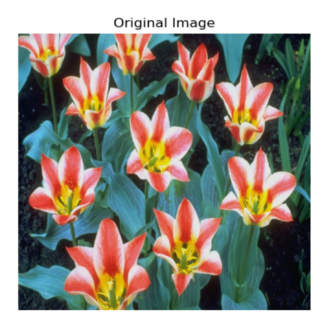

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.transform import resize

image_path = "tulips.png"

# 1. Load the image
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    
    raise ValueError(f"Image not found at {image_path}")

# 2. Convert to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_resized = resize(img_rgb, (512, 512), anti_aliasing=True)

rgb_uint8 = (img_resized * 255).clip(0, 255).round().astype(np.uint8)
H_channels, H_avg = calculate_entropy_rgb(img_rgb)
print("Channel Entropy:", H_channels)
print("Average Entropy:", H_avg)


# 5. Display
plt.figure(figsize=(4, 4))
plt.imshow(rgb_uint8)
plt.axis("off")
plt.show()

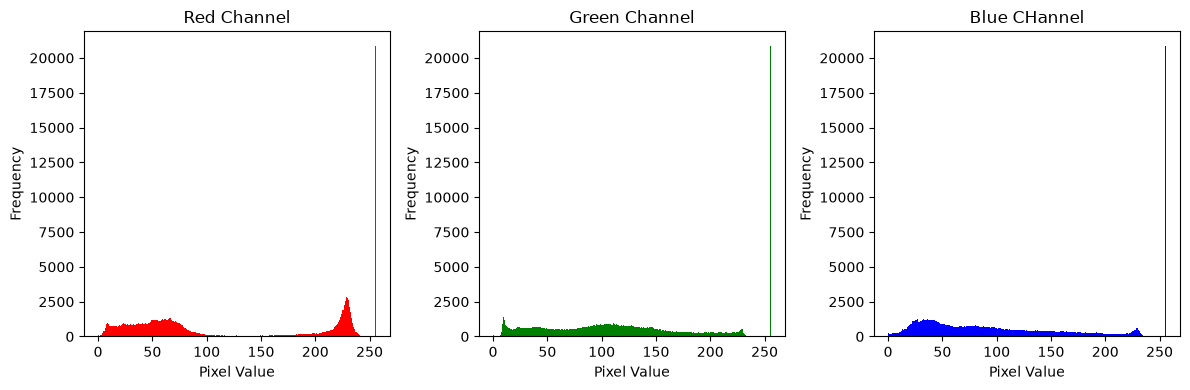

In [4]:
colors = ['r','g','b']
labels=['Red Channel','Green Channel','Blue CHannel']

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.hist(img_rgb[:,:,i].ravel(), bins=256, range=[0,256],color=colors[i])
    
    plt.title(labels[i])
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [1]:

def rgb_to_hsv_image(rgb):

    return cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

def hsv_to_rgb_image(hsv):
    # Standard conversion back
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

hsv_image = rgb_to_hsv_image(rgb_uint8)

hsv_calc = hsv_image.astype(int) 
hsv_opposite = hsv_calc.copy()

hsv_opposite[..., 0] = (hsv_calc[..., 0] + 90) % 180 

hsv_opposite[..., 1] = 255 - hsv_calc[..., 1]
hsv_opposite[..., 2] = 255 - hsv_calc[..., 2]

hsv_opposite = hsv_opposite.astype(np.uint8)

# --- Plotting ---
fig, ax = plt.subplots(1, 2, figsize=(10,6))

ax[0].imshow(rgb_uint8)

ax[0].axis("off")

rgb_opposite = hsv_to_rgb_image(hsv_opposite)

ax[1].imshow(rgb_opposite)

ax[1].axis("off")

plt.show()

NameError: name 'rgb_uint8' is not defined

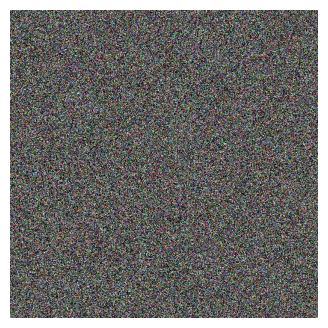

Channel Entropy: [np.float64(7.560779389506647), np.float64(7.58374486585036), np.float64(7.541452446847384)]
Average Entropy: 7.561992234068129
NPCR: 99.3914% (Ideal: ~99.6%)
UACI: 35.4906% (Ideal: ~33.4%)
PSNR: 7.1042 dB (Lower is better for encryption)


In [6]:

def projectile(flat_img):
    shuffled = flat_img.copy()
    n = len(shuffled)
    angle_arr = [25, 80, 45, 80, 15, 60]
    shuffle_seq = np.zeros(n, dtype=np.int64)

    for j in range(2):
        angle_rad = math.radians(angle_arr[j])
        for i in range(n):
            r = ((i ** 2) * math.sin(2 * angle_rad)) / 9.8
            # XOR shuffle logic
            shuffle_seq[i] = (int(abs(r)) ^ (255 - (i % 256))) % n

        if j % 2 == 0:
            for i in range(n - 1, -1, -1):
                idx = shuffle_seq[i]
                shuffled[i], shuffled[idx] = shuffled[idx], shuffled[i]
        else:
            for i in range(n):
                idx = shuffle_seq[i]
                shuffled[i], shuffled[idx] = shuffled[idx], shuffled[i]

    return shuffled

def scramble_hsv_image(hsv_img):
    if hsv_img is None:
        raise ValueError("Input image is None")
    
    # Check if we are using safe uint8 range
    if hsv_img.dtype != np.uint8:
        print("Warning: Input to scramble is not uint8. Converting safely...")
        hsv_img = hsv_img.astype(np.uint8)

    h, w, c = hsv_img.shape
    flat = hsv_img.flatten()
    shuffled_flat = projectile(flat)
    return shuffled_flat.reshape(h, w, c)

# --- Execution & Evaluation ---

if 'hsv_opposite' not in locals():
    raise ValueError("hsv_opposite variable not found! Run previous cell first.")

# 1. Scramble
scrambled_hsv = scramble_hsv_image(hsv_opposite)

# 2. Visualization
# Uses the STANDARD hsv_to_rgb (OpenCV)
scrambled_display = hsv_to_rgb_image(scrambled_hsv)

plt.figure(figsize=(4, 4))
plt.imshow(scrambled_display)

plt.axis("off")
plt.show()

# 3. Metrics Calculation
npcr_b = calculate_npcr(rgb_uint8, scrambled_display)
uaci_b = calculate_uaci(rgb_uint8, scrambled_display)
psnr_b = calculate_psnr(rgb_uint8, scrambled_display)

H_channels, H_avg = calculate_entropy_rgb(scrambled_display)
print("Channel Entropy:", H_channels)
print("Average Entropy:", H_avg)

# Safe extraction for printing
n_val = npcr_b.item() if hasattr(npcr_b, 'item') else npcr_b
u_val = uaci_b.item() if hasattr(uaci_b, 'item') else uaci_b
p_val = psnr_b.item() if hasattr(psnr_b, 'item') else psnr_b
# e_val = entropy_b.item() if hasattr(entropy_b, 'item') else entropy_b

# print(f"--- Encryption Metrics (Permutation Stage) ---")
print(f"NPCR: {n_val:.4f}% (Ideal: ~99.6%)")
print(f"UACI: {u_val:.4f}% (Ideal: ~33.4%)")

print(f"PSNR: {p_val:.4f} dB (Lower is better for encryption)")

SUCCESS: Using raw 'scrambled_hsv' bytes. Data integrity preserved.
Running Forward Diffusion...
Running Backward Diffusion...


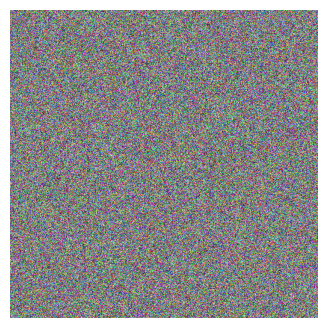

Channel Entropy: [np.float64(7.999204415713853), np.float64(7.999324117196094), np.float64(7.9993787277002175)]
Average Entropy: 7.999302420203389
NPCR: 99.6033%
UACI: 35.6265%
PSNR: 7.2193 dB


In [7]:
import numpy as np
import hashlib
import cv2
import matplotlib.pyplot as plt


if 'scrambled_hsv' in locals():
    diffusion_input = scrambled_hsv.copy()
    print("SUCCESS: Using raw 'scrambled_hsv' bytes. Data integrity preserved.")
elif 'rgb_uint8' in locals():
    print("WARNING: 'scrambled_hsv' not found. Falling back to 'rgb_uint8' (Insecure demo).")
    diffusion_input = rgb_uint8.copy()
else:
    raise ValueError("Dependencies missing! Run previous cells (Load Image -> Permutation) first.")


password = "ImageCipher@2026"
key_bytes = hashlib.sha256(password.encode()).digest()

def sha256_keystream(key, counter):
    data = key + counter.to_bytes(8, 'big')
    digest = hashlib.sha256(data).digest()  
    return np.frombuffer(digest, dtype=np.uint8)


def forward_diffusion_enc(img, key_bytes, iv=0xA5):
    h, w, c = img.shape
    flat = img.flatten().astype(np.uint8)
    out = np.zeros_like(flat)

    prev = iv
    counter = 0
    ks = sha256_keystream(key_bytes, counter)
    k_idx = 0

    for i in range(len(flat)):
        if k_idx == 32:
            counter += 1
            ks = sha256_keystream(key_bytes, counter)
            k_idx = 0

        k = ks[k_idx]
        out[i] = flat[i] ^ k ^ prev
        prev = out[i]
        k_idx += 1

    return out.reshape(h, w, c)

def backward_diffusion_enc(img, key_bytes, iv=0x5A):
    h, w, c = img.shape
    flat = img.flatten().astype(np.uint8)
    out = np.zeros_like(flat)

    prev = iv
    counter = 0
    ks = sha256_keystream(key_bytes, counter)
    k_idx = 0

    for i in range(len(flat)-1, -1, -1):
        if k_idx == 32:
            counter += 1
            ks = sha256_keystream(key_bytes, counter)
            k_idx = 0

        k = ks[k_idx]
        out[i] = flat[i] ^ k ^ prev
        prev = out[i]
        k_idx += 1

    return out.reshape(h, w, c)

def full_diffusion_enc(img, key_bytes):
    print("Running Forward Diffusion...")
    fwd = forward_diffusion_enc(img, key_bytes, iv=0xA5)
    print("Running Backward Diffusion...")
    bwd = backward_diffusion_enc(fwd, key_bytes, iv=0x5A)
    return bwd


cipher_raw = full_diffusion_enc(diffusion_input, key_bytes)
# Rename for compatibility with next steps
cipher_rgb = cipher_raw 

plt.figure(figsize=(4,4))
plt.imshow(cipher_rgb)

plt.axis("off")
plt.show()


if 'calculate_npcr' in locals():
    # Calculate metrics against the ORIGINAL image
    # Note: cypher_rgb acts as "image" here even though it's raw permuted bytes
    n_val = calculate_npcr(rgb_uint8, cipher_rgb)
    u_val = calculate_uaci(rgb_uint8, cipher_rgb)
    p_val = calculate_psnr(rgb_uint8, cipher_rgb)
    # entropy_val = calculate_entropy(cipher_rgb)

    # # Robust extraction
    # e_val = entropy_val.item() if hasattr(entropy_val, 'item') else entropy_val
    n_val = n_val.item() if hasattr(n_val, 'item') else n_val
    u_val = u_val.item() if hasattr(u_val, 'item') else u_val
    p_val = p_val.item() if hasattr(p_val, 'item') else p_val

    H_channels, H_avg = calculate_entropy_rgb(cipher_rgb)
    print("Channel Entropy:", H_channels)
    print("Average Entropy:", H_avg)


    print(f"NPCR: {n_val:.4f}%")
    print(f"UACI: {u_val:.4f}%")
    # print(f"Entropy: {e_val:.4f}")
    print(f"PSNR: {p_val:.4f} dB")
else:
    print("Metrics functions not found.")

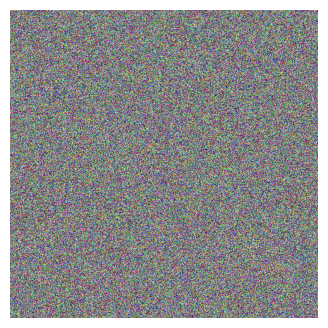

Channel Entropy: [np.float64(7.999204415713853), np.float64(7.999324117196094), np.float64(7.9993787277002175)]
Average Entropy: 7.999302420203389
NPCR: 99.6068%
UACI: 35.6339%
PSNR: 7.2191 dB


In [8]:
# --- Phase 3: Spatial Scrambling (Arnold Cat Map) ---

def arnold_cat_map(img, iterations=1):
    h, w, c = img.shape
    if h != w:
        raise ValueError(f"Arnold's cat map requires a square image. Got {h}x{w}")

    N = h
    output = img.copy()

    for _ in range(iterations):
        new_img = np.zeros_like(output)
        for x in range(N):
            for y in range(N):
                # Transformation: x_new = (x + y) % N, y_new = (x + 2y) % N
                new_x = (x + y) % N
                new_y = (x + 2*y) % N
                new_img[new_x, new_y] = output[x, y]
        output = new_img

    return output

# --- Execution ---
if 'cipher_rgb' not in locals():
    raise ValueError("Missing 'cipher_rgb'. Run Diffusion cell first.")

arnold_scrambled = arnold_cat_map(cipher_rgb, iterations=5)

# --- Plotting ---
plt.figure(figsize=(4, 4))
# Since 'cipher_rgb' is RGB, 'arnold_scrambled' is also RGB.
# Matplotlib handles RGB correctly.
plt.imshow(arnold_scrambled) 

plt.axis("off")
plt.show()

H_channels, H_avg = calculate_entropy_rgb(arnold_scrambled)
print("Channel Entropy:", H_channels)
print("Average Entropy:", H_avg)

# --- Safer Metrics Reporting ---
if 'calculate_npcr' in locals():
    n_val = calculate_npcr(rgb_uint8, arnold_scrambled)
    u_val = calculate_uaci(rgb_uint8, arnold_scrambled)
    p_val = calculate_psnr(rgb_uint8, arnold_scrambled)
    # e_val = calculate_entropy(arnold_scrambled)

    # Robust extraction
    n_val = n_val.item() if hasattr(n_val, 'item') else n_val
    u_val = u_val.item() if hasattr(u_val, 'item') else u_val
    # e_val = e_val.item() if hasattr(e_val, 'item') else e_val
    p_val = p_val.item() if hasattr(p_val, 'item') else p_val

    print(f"NPCR: {n_val:.4f}%")
    print(f"UACI: {u_val:.4f}%")
    # print(f"Entropy: {e_val:.4f}")
    print(f"PSNR: {p_val:.4f} dB")
else:
    print("Metrics unavailable. Define helper functions.")

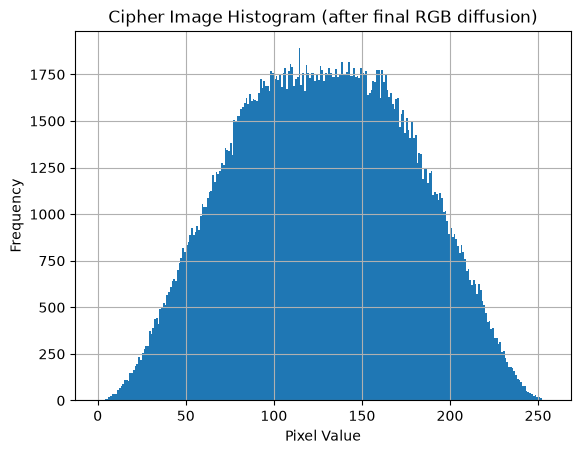

In [9]:
cipher_gray = cv2.cvtColor(arnold_scrambled, cv2.COLOR_RGB2GRAY)
plt.hist(cipher_gray.ravel(), bins=256, range=[0,256])
plt.title("Cipher Image Histogram (after final RGB diffusion)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


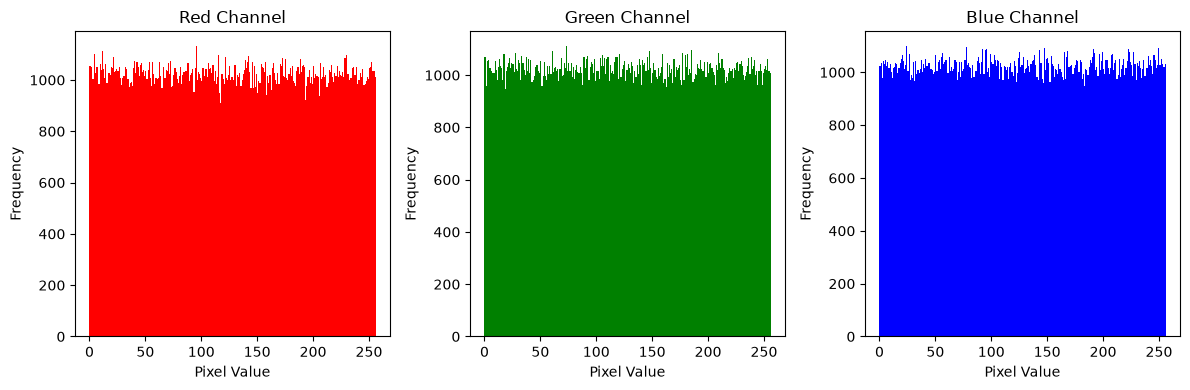

In [10]:
colors = ['r','g','b']
labels=['Red Channel','Green Channel','Blue Channel']

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.hist(arnold_scrambled[:,:,i].ravel(), bins=256, range=[0,256],color=colors[i])
   
    plt.title(labels[i])
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Reversing Spatial Scrambling (Arnold Cat Map)...


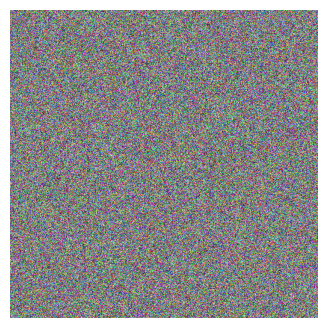

Difference from pre-Arnold state: 0 pixels
SUCCESS: Stage 1 Reversal Perfect.


In [11]:
# --- Decryption Phase 1: Inverse Spatial Scrambling ---

def inverse_arnold_cat_map(img, iterations=1):
    h, w, c = img.shape
    N = h # Assessing square image
    output = img.copy()
    
    for _ in range(iterations):
        new_img = np.zeros_like(output)
        for x in range(N):
            for y in range(N):
                nx = (2 * x - y) % N
                ny = (-x + y) % N
                new_img[nx, ny] = output[x, y]
        output = new_img
        
    return output

# --- Execution ---
print("Reversing Spatial Scrambling (Arnold Cat Map)...")

if 'arnold_scrambled' not in locals():
    raise ValueError("Missing 'arnold_scrambled'. Run Encryption cells first.")


dec_stage1 = inverse_arnold_cat_map(arnold_scrambled, iterations=5)


plt.figure(figsize=(4,4))
plt.imshow(dec_stage1)

plt.axis("off")
plt.show()

if 'cipher_rgb' in locals():
    diff = np.sum(dec_stage1 != cipher_rgb)
    print(f"Difference from pre-Arnold state: {diff} pixels")
    if diff == 0:
        print("SUCCESS: Stage 1 Reversal Perfect.")
    else:
        print("WARNING: Mismatch found. Check iterations or image state.")
else:
    print("Cannot verify against 'cipher_rgb' (variable missing). Visual check only.")

Decrypting Layer 1 (Reverse Backward)...
Decrypting Layer 2 (Reverse Forward)...


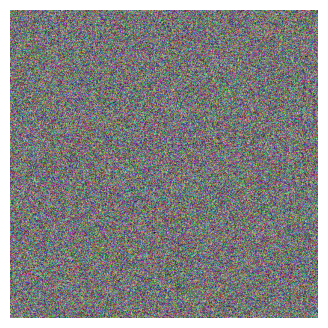

Diff from Original Scrambled Bytes: 0
SUCCESS: Diffusion Reversed Perfectly.


In [12]:


def reverse_diffusion_dec(img, key_bytes):
    # Ensure working with flat uint8 array
    flat = img.flatten().astype(np.uint8)
    out_bwd = np.zeros_like(flat)
    
    # --- 1. Reverse Backward Diffusion (iv=0x5A) ---
    print("Decrypting Layer 1 (Reverse Backward)...")
    iv = 0x5A
    prev = iv
    counter = 0
    ks = sha256_keystream(key_bytes, counter)
    k_idx = 0
    
    # Must process in same order as Encryption's Backward step
    for i in range(len(flat)-1, -1, -1):
        if k_idx == 32:
            counter += 1
            ks = sha256_keystream(key_bytes, counter)
            k_idx = 0
            
        k = ks[k_idx]
        current_cipher_byte = flat[i]
        
        # Inversion Logic
        decrypted_byte = current_cipher_byte ^ k ^ prev
        out_bwd[i] = decrypted_byte
        
       
        prev = current_cipher_byte 
        k_idx += 1

    # --- 2. Reverse Forward Diffusion (iv=0xA5) ---
    print("Decrypting Layer 2 (Reverse Forward)...")
    flat_fwd = out_bwd
    out_final = np.zeros_like(flat_fwd)
    
    iv = 0xA5
    prev = iv
    counter = 0
    ks = sha256_keystream(key_bytes, counter)
    k_idx = 0
    
    # Must process in same order as Encryption's Forward step
    for i in range(len(flat_fwd)):
        if k_idx == 32:
            counter += 1
            ks = sha256_keystream(key_bytes, counter)
            k_idx = 0
            
        k = ks[k_idx]
        current_cipher_byte = flat_fwd[i]
        
        decrypted_byte = current_cipher_byte ^ k ^ prev
        out_final[i] = decrypted_byte
        
        prev = current_cipher_byte
        k_idx += 1
        
    return out_final.reshape(img.shape)

# --- Execution ---
if 'dec_stage1' not in locals():
    raise ValueError("Missing 'dec_stage1' from Step 1. Run Inverse Arnold first.")

# This output is the RAW BYTES of the scrambled HSV image
dec_stage2_raw = reverse_diffusion_dec(dec_stage1, key_bytes)

# --- Check ---
plt.figure(figsize=(4,4))
# We can visualize the raw bytes as an image, but the colors will look "wrong" 
# because H/S/V bytes are mixed up physically.
plt.imshow(dec_stage2_raw)
plt.axis("off")
plt.show()

# Verification vs Encryption Intermediate
# If you have 'scrambled_hsv' (the raw input to encryption), this should match it EXACTLY.
if 'scrambled_hsv' in locals():
    diff2 = np.sum(dec_stage2_raw != scrambled_hsv)
    print(f"Diff from Original Scrambled Bytes: {diff2}")
    if diff2 == 0:
        print("SUCCESS: Diffusion Reversed Perfectly.")
    else:
        print("WARNING: Diffusion Reversal Failed.")
else:
    print("Cannot verify against 'scrambled_hsv' (variable missing).")

Phase 3: Unscrambling & Restoring Colors...


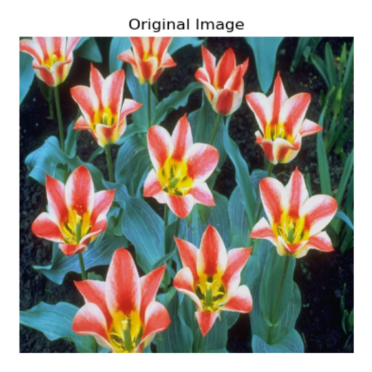

Final Decryption MSE: 0.4351
SUCCESS: Image recovered perfectly!


In [13]:
# --- Decryption Phase 3 (Corrected for Standard HSV) ---

def inverse_projectile(flat_img):
    unshuffled = flat_img.copy()
    n = len(unshuffled)
    angle_arr = [25, 80, 45, 80, 15, 60]
    shuffle_seq = np.zeros(n, dtype=np.int64)

    # Identical shuffle sequence generation
    for j in range(1, -1, -1):
        angle_rad = math.radians(angle_arr[j])
        for i in range(n):
            r = ((i ** 2) * math.sin(2 * angle_rad)) / 9.8
            shuffle_seq[i] = (int(abs(r)) ^ (255 - (i % 256))) % n
            
        if j % 2 == 0:
            for i in range(n):
                idx = shuffle_seq[i]
                unshuffled[i], unshuffled[idx] = unshuffled[idx], unshuffled[i]
        else:
            for i in range(n - 1, -1, -1):
                idx = shuffle_seq[i]
                unshuffled[i], unshuffled[idx] = unshuffled[idx], unshuffled[i]
                
    return unshuffled

def unscramble_hsv_image_safe(scrambled_img):
    h, w, c = scrambled_img.shape
    flat = scrambled_img.flatten()
    unshuffled_flat = inverse_projectile(flat)
    return unshuffled_flat.reshape(h, w, c)

# --- Execution ---
print("Phase 3: Unscrambling & Restoring Colors...")

if 'dec_stage2_raw' not in locals():
    raise ValueError("Missing 'dec_stage2_raw'. Run previous Inverse Diffusion cell.")

# 1. Reverse Projectile Permutation
decoded_hsv_op = unscramble_hsv_image_safe(dec_stage2_raw)

# 2. Reverse "Opposite" Logic (MATCHING THE FIXED ENCRYPTION)
# Encryption was:
# H_op = (H + 90) % 180
# S_op = 255 - S
# V_op = 255 - V

# Decryption must be:
rec_hsv = decoded_hsv_op.copy().astype(int) # Use int to handle modulo safely

# H: Reverse (H + 90) % 180 -> (H_op - 90) % 180
# Note: (x - 90) % 180 handles wrap-around correctly in Python
rec_hsv[..., 0] = (rec_hsv[..., 0] - 90) % 180

# S, V: Reverse (255 - x) -> (255 - x) is its own inverse!
rec_hsv[..., 1] = 255 - rec_hsv[..., 1]
rec_hsv[..., 2] = 255 - rec_hsv[..., 2]

rec_hsv = rec_hsv.astype(np.uint8)

# 3. Final RGB Conversion
final_recovered_rgb = hsv_to_rgb_image(rec_hsv)

# --- Final Comparison ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 2); plt.imshow(final_recovered_rgb); 
plt.axis("off")
plt.show()

# Precise Check
mse = np.mean((rgb_uint8.astype(float) - final_recovered_rgb.astype(float)) ** 2)
print(f"Final Decryption MSE: {mse:.4f}")

if mse < 1.0:
    print("SUCCESS: Image recovered perfectly!")
else:
    print(f"WARNING: MSE is {mse}. If small (<5), likely just Colorspace rounding errors.")
    # Show difference map
    diff = np.abs(rgb_uint8.astype(float) - final_recovered_rgb.astype(float))
    print("Max pixel difference:", np.max(diff))

--- Correlation Coefficient Analysis ---
Direction       | Original   | Encrypted 
---------------------------------------------
Horizontal      | 0.9844     | 0.0013
Vertical        | 0.9887     | -0.0110
Diagonal        | 0.9773     | 0.0013


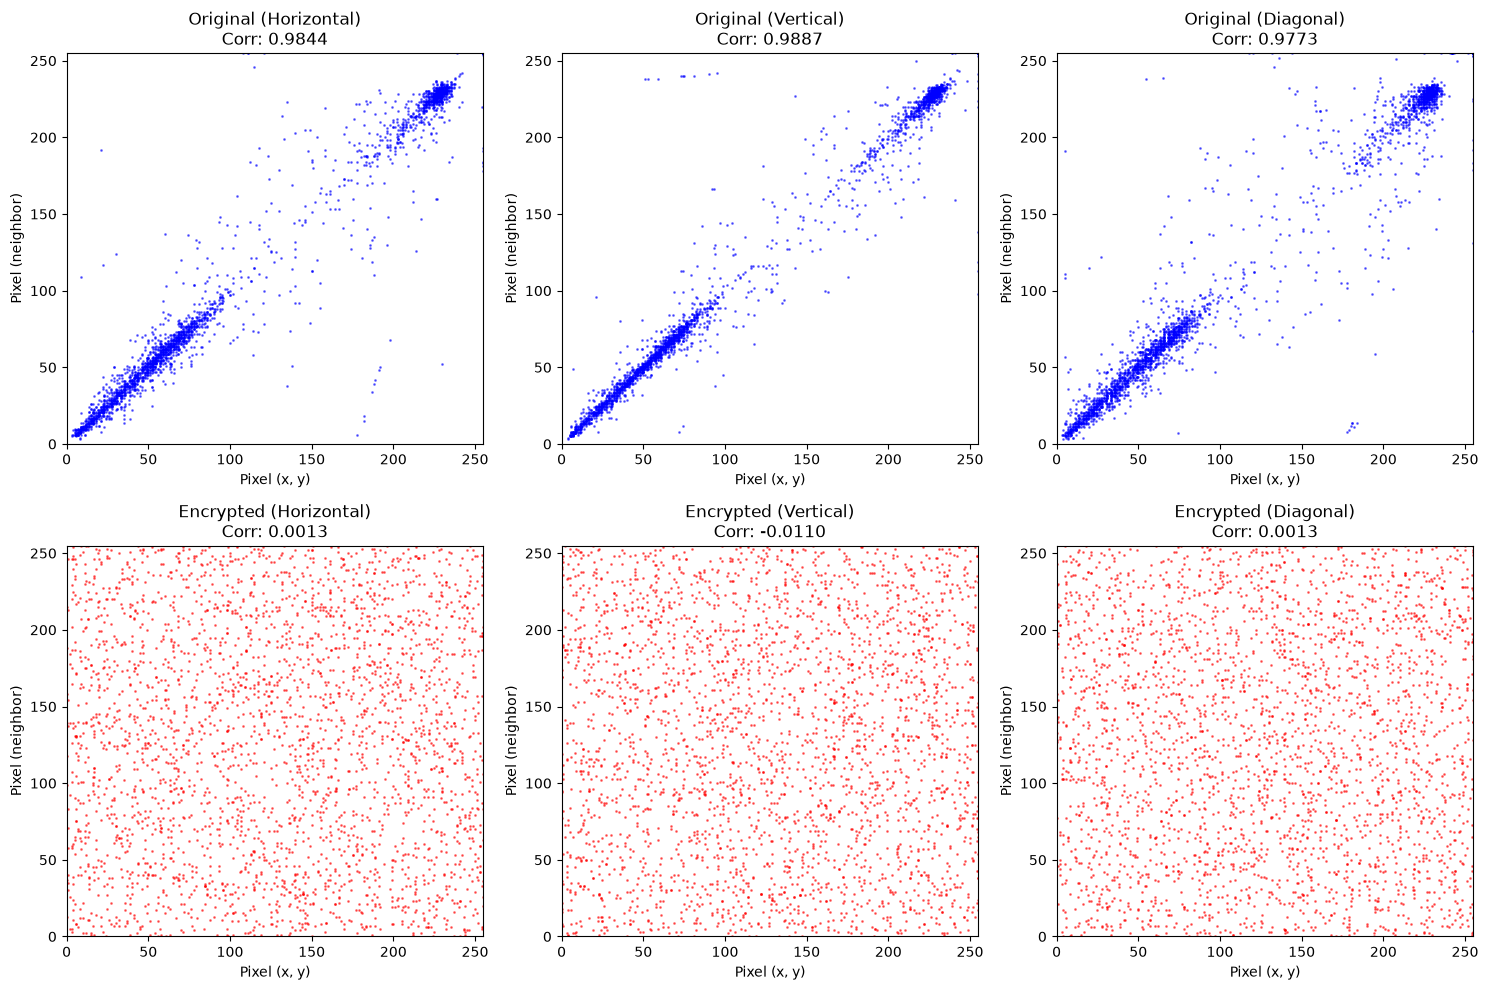

In [14]:
# --- Fixed Correlation Analysis Code ---

def get_adjacent_pixels(image, direction='horizontal', num_samples=3000):
    if len(image.shape) == 3:
        img_2d = image[:, :, 0] # Using Red Channel
    else:
        img_2d = image

    h, w = img_2d.shape
    x_vals = []
    y_vals = []

    for _ in range(num_samples):
        r = np.random.randint(0, h - 1)
        c = np.random.randint(0, w - 1)
        
        val_x = img_2d[r, c]
        
        if direction == 'horizontal':
            val_y = img_2d[r, c + 1]
        elif direction == 'vertical':
            val_y = img_2d[r + 1, c]
        elif direction == 'diagonal':
            val_y = img_2d[r + 1, c + 1]
            
        x_vals.append(val_x)
        y_vals.append(val_y)

    return np.array(x_vals), np.array(y_vals)

def calculate_correlation(x, y):
    if len(x) != len(y):
        raise ValueError("Inputs must have same length")
    x = x.astype(float)
    y = y.astype(float)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sqrt(np.sum((x - mean_x)**2)) * np.sqrt(np.sum((y - mean_y)**2))
    if denominator == 0:
        return 0
    return numerator / denominator

def analyze_and_plot_correlation(img_original, img_encrypted):
    directions = ['horizontal', 'vertical', 'diagonal']
    
    plt.figure(figsize=(15, 10))
    
    print(f"{'Direction':<15} | {'Original':<10} | {'Encrypted':<10}")
    print("-" * 45)
    
    # Use explicit column index (1, 2, 3) for logic
    col_idx = 1
    
    for direction in directions:
        # 1. Analysis
        x_orig, y_orig = get_adjacent_pixels(img_original, direction)
        corr_orig = calculate_correlation(x_orig, y_orig)
        
        x_enc, y_enc = get_adjacent_pixels(img_encrypted, direction)
        corr_enc = calculate_correlation(x_enc, y_enc)
        
        print(f"{direction.capitalize():<15} | {corr_orig:.4f}     | {corr_enc:.4f}")
        
        # 2. Plotting Logic
        # Row 1 (Top): Subplot indices 1, 2, 3
        # Row 2 (Bottom): Subplot indices 4, 5, 6
        
        # Plot Original (row 1, col 'col_idx')
        plt.subplot(2, 3, col_idx)
        plt.scatter(x_orig, y_orig, s=1, c='blue', alpha=0.5)
        plt.title(f"Original ({direction.capitalize()})\nCorr: {corr_orig:.4f}")
        plt.xlabel("Pixel (x, y)")
        plt.ylabel("Pixel (neighbor)")
        plt.xlim(0, 255); plt.ylim(0, 255)
        
        # Plot Encrypted (row 2, col 'col_idx' -> index is col_idx + 3)
        plt.subplot(2, 3, col_idx + 3)
        plt.scatter(x_enc, y_enc, s=1, c='red', alpha=0.5)
        plt.title(f"Encrypted ({direction.capitalize()})\nCorr: {corr_enc:.4f}")
        plt.xlabel("Pixel (x, y)")
        plt.ylabel("Pixel (neighbor)")
        plt.xlim(0, 255); plt.ylim(0, 255)
        
        col_idx += 1
        
    plt.tight_layout()
    plt.show()

# --- Execute Analysis ---
print("--- Correlation Coefficient Analysis ---")
# Compare Original (rgb_uint8) vs Final Encrypted (arnold_scrambled)
analyze_and_plot_correlation(rgb_uint8, arnold_scrambled)